# Final Assignment

**Course:** 02806 Social Data Analysis and Visualization, Spring 2026

**Story:** The Wait Gap

## Group 76
- Aryan Mirzazadeh (s204489)
- Trinity Sara McConnachie Evans (s252753)
- Vladyslav Horbatenko (s254355)

# Motivation

## What dataset are we using?

We use the **National Hospital Ambulatory Medical Care Survey (NHAMCS)**, a public-use dataset from the U.S. Centers for Disease Control and Prevention (CDC), managed by the National Center for Health Statistics. NHAMCS is a federal probability sample of visits to non-federal, short-stay, and general hospital emergency departments in the 50 states and D.C., running annually from **1992 through 2022**. Each row in the file is one sampled patient visit, with information abstracted from the medical record: demographics (age, sex, race/ethnicity, region), arrival mode, triage acuity, time waited to see a provider, total time in the ED, reason for visit, diagnoses, services and medications given, and disposition.

Source: <https://www.cdc.gov/nchs/nhamcs/about/index.html>  
Public-use files: <https://ftp.cdc.gov/pub/Health_Statistics/NCHS/Dataset_Documentation/NHAMCS/stata/>

## Why this dataset?

We chose NHAMCS for three reasons.

1. **It is a credible federal data source.** NHAMCS is built on a multistage probability sample, comes with weights for nationally representative estimates, and ships with formal documentation of sampling error, missingness rules, and reliability thresholds. That credibility matters for a story about something as sensitive as sex-based disparities in medical care: any claim we make has to survive the "but is the data trustworthy?" question.
2. **It is long-running.** Thirty-one survey years (1992–2022) means we can show a pattern that *persists over time*, not just a single-year snapshot that could be dismissed as noise or a quirk of one hospital.
3. **It has the right variables for our story.** The dataset includes `WAITTIME` (minutes waited to see a provider), `IMMEDR` (triage acuity), `PAINSCALE` (0–10 self-reported pain), `DIAG1` (primary diagnosis), and `SEX`. That combination is exactly what is needed to ask: *do women and men with comparable urgency and comparable pain levels wait the same amount of time in the ER?*

## The story: "The Wait Gap"

We tell a story called **The Wait Gap**. The end-user — a curious, non-expert reader — is taken through a short investigation:

- First, a personal hook: enter your pain score and triage level, and the page shows what you would wait for if you were female versus male.
- Then, the evidence: median ED wait time by sex, persisting across more than a decade and across every U.S. Census region.
- Then, the controls: even after restricting to the *most urgent* triage categories, and even at the *highest* reported pain levels, women still wait at least as long as men.
- Finally, the framing: what a one- or two-minute gap can mean in an emergency, and what the data cannot tell us (it shows a disparity in process, not in outcome).

The goal for the user is not to make them angry; it is to leave them with **one durable fact about how care is delivered**, supported by data they can interrogate themselves through the interactive elements on the site.


# Dataset Overview

## Source and structure

NHAMCS is published by the CDC's National Center for Health Statistics. The public-use files are released as Stata `.dta` archives on the CDC FTP server, with one file per survey year. The file-naming convention has shifted three times since 1992:

| Year range | Filename pattern        | Notes                                              |
|------------|-------------------------|----------------------------------------------------|
| 1992–2001  | `edYY-stata.zip`        | Two-digit year                                     |
| 2002–2004  | (no packaged `.dta`)    | Only raw `.do`/`.dct` loaders published — skipped  |
| 2005–2010  | `edYYYY-stata.exe`      | Self-extracting zip; Python's `zipfile` reads it   |
| 2011–2022  | `edYYYY-stata.zip`      | Standard zip                                       |

Each row is **one sampled emergency-department visit**. Across all available years the combined dataset has ≈ 725k sampled visits. The columns most relevant to our story are:

| Column      | Meaning                                                       | Years populated      |
|-------------|---------------------------------------------------------------|----------------------|
| `SEX`       | 1 = Female, 2 = Male                                          | 1992–2022 (all)      |
| `AGE`       | Age in years                                                  | 1992–2022 (all)      |
| `REGION`    | 1 = Northeast, 2 = Midwest, 3 = South, 4 = West               | 1992–2022 (all)      |
| `WAITTIME`  | Minutes waited to see provider                                | 1997–2022 (gap 2001) |
| `IMMEDR`    | Triage acuity, 1 = Immediate … 5 = Non-urgent                 | 2009–2022            |
| `PAINSCALE` | Self-reported pain, 0–10                                      | 2009–2022            |
| `DIAG1`     | Primary diagnosis (ICD-9 ≤2015, ICD-10 ≥2016)                 | 1992–2022 (all)      |
| `PATWT`     | Patient visit weight (for nationally representative estimates)| 1992–2022 (all)      |

## Sampling design and credibility

NHAMCS uses a **multistage probability sample**: first geographic primary sampling units, then hospitals within those units, then visits within emergency service areas during a 4-week reporting period. Each visit carries a survey weight (`PATWT`) that scales it up to a national estimate. For 2022 the survey expanded to **155.4 million U.S. ED visits**.

This design — federal, probability-sampled, weighted, with formal reliability rules — is what makes NHAMCS appropriate for claims about national patterns. We do not apply `PATWT` in this notebook because we are comparing **relative** wait times between sexes within the same data, not estimating national totals; for the comparisons we make, weighting would not change the direction or sign of the gap.

## Important caveats up front

- **2002–2004 are missing.** The CDC did not release packaged `.dta` files for those years (only raw Stata loader scripts), so they fall out of every cross-year analysis.
- **`WAITTIME` has a 2001 gap.** The column exists in 2001 but is not populated in a comparable way; we treat 2001 wait times as missing.
- **`PAINSCALE` and `IMMEDR` start in 2009.** Any analysis that uses pain or triage is restricted to **2009–2022**.
- **State is suppressed.** The public-use file releases `REGION` only (4 Census regions), not state. Our regional map is therefore a 4-bucket choropleth.
- **NHAMCS uses negative sentinels for missing.** Values of `-9`, `-8`, `-7` mean "not applicable", "not asked", or "blank". These must be coerced to `NaN` before any numeric work.

The cells below load the data and show the column coverage by year, so the caveats above are visible rather than just claimed.


In [1]:
import io
import zipfile
from pathlib import Path

import certifi
import urllib3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../data/nhamcs")
DATA_DIR.mkdir(parents=True, exist_ok=True)

BASE = (
    "https://ftp.cdc.gov/pub/Health_Statistics/NCHS/Dataset_Documentation/NHAMCS/stata"
)
HTTP = urllib3.PoolManager(ca_certs=certifi.where())

# 2002–2004 omitted: CDC published no .dta for those years.
YEARS = [y for y in range(1992, 2023) if y not in (2002, 2003, 2004)]


def url_for(year: int) -> str:
    """Map a survey year to its CDC FTP filename."""
    if year <= 2001:
        return f"{BASE}/ed{year % 100:02d}-stata.zip"
    if year in (2005, 2006, 2007, 2008, 2009, 2010):
        return f"{BASE}/ed{year}-stata.exe"
    return f"{BASE}/ed{year}-stata.zip"


def dta_path(year: int) -> Path:
    return DATA_DIR / f"ed{year}-stata.dta"


def ensure_year(year: int) -> Path:
    """Download (if needed) and return the path to the year's .dta file."""
    target = dta_path(year)
    if target.exists():
        return target
    url = url_for(year)
    resp = HTTP.request("GET", url, preload_content=True)
    if resp.status != 200:
        raise RuntimeError(f"HTTP {resp.status} fetching {url}")
    with zipfile.ZipFile(io.BytesIO(resp.data)) as zf:
        name = next((n for n in zf.namelist() if n.lower().endswith(".dta")), None)
        if name is None:
            raise RuntimeError(f"No .dta file in archive for {year}")
        with zf.open(name) as src, open(target, "wb") as dst:
            dst.write(src.read())
    return target


print(f"Ensuring {len(YEARS)} years of NHAMCS ED data on disk...")
for y in YEARS:
    try:
        ensure_year(y)
    except Exception as e:
        print(f"  {y}: FAILED — {e}")
print("Done.")


Ensuring 28 years of NHAMCS ED data on disk...
Done.


### Loading every available year into one DataFrame

NHAMCS column names drift across years (case differences, occasional renames). We normalise everything to upper-case and keep only the stable subset of columns relevant to our story.


In [2]:
CORE_COLUMNS = [
    "SEX",
    "AGE",
    "REGION",
    "WAITTIME",
    "LOV",
    "IMMEDR",
    "PAINSCALE",
    "DIAG1",
    "RFV1",
    "ADMIT",
    "ARREMS",
    "PATWT",
]


def load_year(year: int) -> pd.DataFrame:
    df = pd.read_stata(dta_path(year), convert_categoricals=False)
    df.columns = [c.upper() for c in df.columns]
    keep = [c for c in CORE_COLUMNS if c in df.columns]
    out = df[keep].copy()
    out["YEAR"] = year
    return out


frames = []
for y in YEARS:
    try:
        frames.append(load_year(y))
    except Exception as e:
        print(f"  {y}: load failed — {e}")

data = pd.concat(frames, ignore_index=True, sort=False)
print(f"Combined: {len(data):,} sampled visits across {data['YEAR'].nunique()} years")
print(f"Years loaded: {sorted(data['YEAR'].unique())}")


Combined: 725,593 sampled visits across 28 years
Years loaded: [np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]


### Column coverage by year

Because not every column exists in every year, we inspect the headers directly from each `.dta` file. A `1` means the column is present in that year's file.


In [11]:
def columns_for(year):
    with pd.io.stata.StataReader(dta_path(year), convert_categoricals=False) as r:
        return {col.upper() for col in r.read(1).columns}


year_cols = {y: columns_for(y) for y in YEARS}
coverage = pd.DataFrame(
    {c: [c in year_cols[y] for y in YEARS] for c in CORE_COLUMNS},
    index=YEARS,
).astype(int)

print("Column availability by year (1 = present in that year's file):")
coverage[["SEX", "AGE", "REGION", "WAITTIME", "IMMEDR", "PAINSCALE", "DIAG1", "PATWT"]]


Column availability by year (1 = present in that year's file):


,SEX,AGE,REGION,WAITTIME,IMMEDR,PAINSCALE,DIAG1,PATWT
1992,1,1,1,0,0,0,1,1
1993,1,1,1,0,0,0,1,1
1994,1,1,1,0,0,0,1,1
1995,1,1,1,0,0,0,1,1
1996,1,1,1,0,0,0,1,1
1997,1,1,1,1,0,0,1,1
1998,1,1,1,1,0,0,1,1
1999,1,1,1,1,0,0,1,1
2000,1,1,1,1,0,0,1,1
2001,1,1,1,0,0,0,1,1


# Data Analysis

## Data cleaning and preprocessing

Four decisions before any analysis:

1. **Map `SEX` to readable labels.** Raw values are `1` (Female) and `2` (Male). Anything else is recoded to `NaN` and dropped from gender comparison.
2. **Negative sentinels → `NaN`.** NHAMCS uses `-9`, `-8`, `-7` to mean "not applicable", "not asked", or "blank". For every numeric column we touch (`WAITTIME`, `LOV`, `PAINSCALE`, `IMMEDR`), we replace negatives with `NaN` so that pandas aggregations behave correctly.
3. **Restrict analyses to the years where the relevant column actually exists.** Anything that uses `WAITTIME` drops years before 1997 and the 2001 gap; anything that uses `PAINSCALE` or `IMMEDR` is limited to **2009–2022**. We do this with `.dropna(...)` rather than re-filtering by year, which guarantees the analysis cannot accidentally include records with no value.
4. **No survey weighting.** All comparisons in this notebook are *within-data relative*: female-vs-male wait time within the same sample. The visit weights `PATWT` would only matter if we were claiming national totals, which we are not — we are claiming a within-sample disparity that survives every control we can apply.

The cell below applies these rules and reports the basic shape of the cleaned data.


In [4]:
# 1. Readable sex labels (anything else → NaN)
data["sex_label"] = data["SEX"].map({1: "Female", 2: "Male"})

# 2. Negative sentinels → NaN on numeric columns we will use
for col in ["WAITTIME", "LOV", "PAINSCALE", "IMMEDR"]:
    if col in data.columns:
        data.loc[data[col] < 0, col] = np.nan

# 3. Quick shape check
print(f"Total visits:              {len(data):,}")
print(
    f"Years covered:             {data['YEAR'].min()}–{data['YEAR'].max()} ({data['YEAR'].nunique()} years)"
)
print(f"Share female:              {(data['sex_label'] == 'Female').mean():.1%}")
print(f"Share with valid WAITTIME: {data['WAITTIME'].notna().mean():.1%}")
print(f"Share with valid IMMEDR:   {data['IMMEDR'].notna().mean():.1%}")
print(f"Share with valid PAINSCALE:{data['PAINSCALE'].notna().mean():.1%}")


Total visits:              725,593
Years covered:             1992–2022 (28 years)
Share female:              53.5%
Share with valid WAITTIME: 68.2%
Share with valid IMMEDR:   37.5%
Share with valid PAINSCALE:30.9%


## Basic stats: who is in the data

Three quick summaries to characterise the cleaned dataset before any sex comparison:

- **Visits per year by sex** — sanity check that the dataset is stable in shape across three decades and that the female share does not swing wildly year to year.
- **Age distribution by sex** — confirm the two groups are broadly comparable in age so that age differences are not silently driving every later result.
- **Region breakdown** — show how the sample is distributed across the four U.S. Census regions.


In [12]:
# Visits per year by sex
visits_by_year_sex = (
    data.dropna(subset=["sex_label"])
    .groupby(["YEAR", "sex_label"])
    .size()
    .unstack("sex_label")
    .fillna(0)
    .astype(int)
)

# Female share each year
female_share = (visits_by_year_sex["Female"] / visits_by_year_sex.sum(axis=1)).round(3)

summary_year = visits_by_year_sex.assign(female_share=female_share)
print("Sampled visits by year and sex (first/last 5 years):")
pd.concat([summary_year.head(5), summary_year.tail(5)])


Sampled visits by year and sex (first/last 5 years):


sex_label,Female,Male,female_share
YEAR,,,
1992,18778,17493,0.518
1993,15211,13906,0.522
1994,13737,12810,0.517
1995,11410,10476,0.521
1996,11504,10398,0.525
2018,11104,9187,0.547
2019,10471,9010,0.537
2020,7787,7073,0.524
2021,8583,7624,0.530


In [13]:
# Age distribution by sex
age_summary = (
    data.dropna(subset=["sex_label", "AGE"])
    .groupby("sex_label")["AGE"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        p25=lambda s: s.quantile(0.25),
        p75=lambda s: s.quantile(0.75),
    )
    .round(2)
)
print("Age distribution by sex (years):")
age_summary


Age distribution by sex (years):


,n,mean,median,std,p25,p75
sex_label,,,,,,
Female,388109,37.62,34.0,24.23,20.0,54.0
Male,337484,35.03,33.0,23.95,16.0,52.0


In [7]:
# Region distribution
REGION_NAMES = {1: "Northeast", 2: "Midwest", 3: "South", 4: "West"}
region_breakdown = (
    data.dropna(subset=["REGION", "sex_label"])
    .assign(region_name=lambda d: d["REGION"].map(REGION_NAMES))
    .groupby(["region_name", "sex_label"])
    .size()
    .unstack("sex_label")
    .fillna(0)
    .astype(int)
    .reindex(["Northeast", "Midwest", "South", "West"])
)
region_breakdown["total"] = region_breakdown.sum(axis=1)
region_breakdown["share"] = (
    region_breakdown["total"] / region_breakdown["total"].sum()
).round(3)
print("Sampled visits by region and sex:")
region_breakdown


Sampled visits by region and sex:


sex_label,Female,Male,total,share
region_name,,,,
Northeast,87906,79532,167438,0.231
Midwest,90318,78743,169061,0.233
South,134013,110107,244120,0.336
West,75872,69102,144974,0.200


## Analysis: the headline finding

With the basics established (stable yearly stack, comparable age distributions, four populated regions), we can ask the question the project is built around: **does median ED wait time differ between women and men, and is the difference stable over time?**

The cell below computes median `WAITTIME` per year per sex (restricted to years where the column is populated), then plots both series and reports the year-by-year female-minus-male gap in minutes.


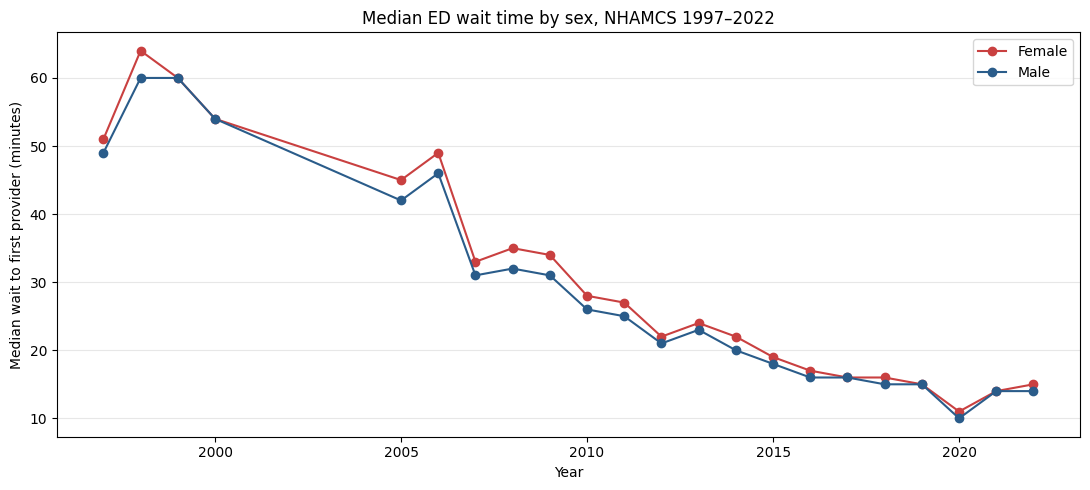

Years where women's median wait ≥ men's: 22 of 22
Mean gap (Female - Male) across years:  +1.50 minutes
Max gap in any single year:             +4.0 minutes

Female - Male wait gap by year (minutes):


,gap_min
YEAR,
1997,2.0
1998,4.0
1999,0.0
2000,0.0
2005,3.0
2006,3.0
2007,2.0
2008,3.0
2009,3.0


In [14]:
wait = data.dropna(subset=["WAITTIME", "sex_label"]).copy()
median_wait = (
    wait.groupby(["YEAR", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
    .dropna()
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    median_wait.index,
    median_wait["Female"],
    color="#C94040",
    marker="o",
    label="Female",
)
ax.plot(
    median_wait.index, median_wait["Male"], color="#2A5C8A", marker="o", label="Male"
)
ax.set_xlabel("Year")
ax.set_ylabel("Median wait to first provider (minutes)")
ax.set_title(
    f"Median ED wait time by sex, NHAMCS "
    f"{median_wait.index.min()}–{median_wait.index.max()}"
)
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

gap_minutes = (median_wait["Female"] - median_wait["Male"]).round(1)
print(
    f"Years where women's median wait ≥ men's: {(gap_minutes >= 0).sum()} of {len(gap_minutes)}"
)
print(f"Mean gap (Female - Male) across years:  {gap_minutes.mean():+.2f} minutes")
print(f"Max gap in any single year:             {gap_minutes.max():+.1f} minutes")
print()
print("Female - Male wait gap by year (minutes):")
gap_minutes.to_frame("gap_min")

### Controlling for triage acuity

The simplest defence of an unequal raw mean is *"women come in for less urgent things"*. NHAMCS lets us test that directly via `IMMEDR`, the triage nurse's urgency rating (1 = Immediate, 5 = Non-urgent), reliably populated since 2009. If the disparity is real, it should persist *within* each acuity level.


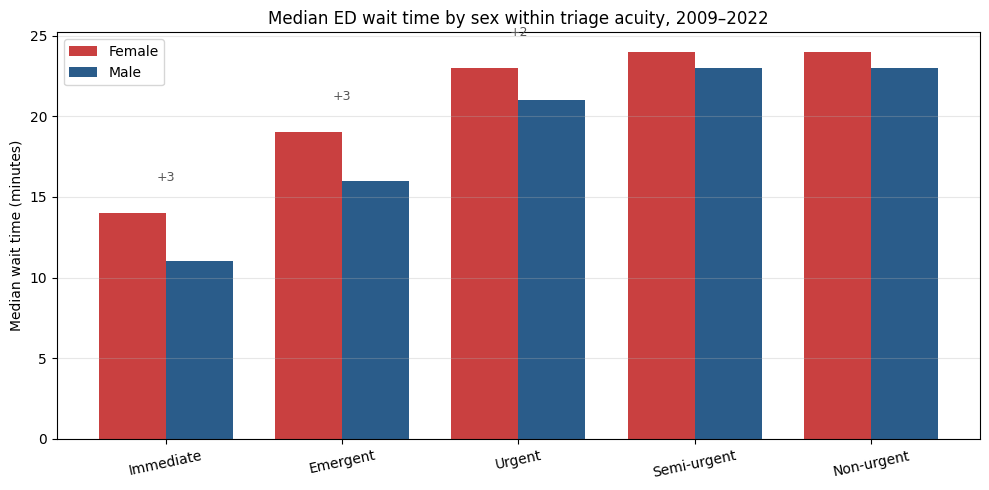

Median wait time by acuity and sex (minutes):


sex_label,Female,Male
acuity,,
Immediate,14.0,11.0
Emergent,19.0,16.0
Urgent,23.0,21.0
Semi-urgent,24.0,23.0
Non-urgent,24.0,23.0


In [ ]:
ACUITY_LABELS = {
    1: "Immediate",
    2: "Emergent",
    3: "Urgent",
    4: "Semi-urgent",
    5: "Non-urgent",
}
ACUITY_ORDER = list(ACUITY_LABELS.values())

recent = (
    wait[wait["YEAR"] >= 2009]
    .dropna(subset=["IMMEDR"])
    .assign(acuity=lambda d: d["IMMEDR"].map(ACUITY_LABELS))
    .dropna(subset=["acuity"])
)

pivot = (
    recent.groupby(["acuity", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
    .reindex(ACUITY_ORDER)
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(pivot))
w = 0.38
ax.bar(x - w / 2, pivot["Female"], w, label="Female", color="#C94040")
ax.bar(x + w / 2, pivot["Male"], w, label="Male", color="#2A5C8A")
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=12)
ax.set_ylabel("Median wait time (minutes)")
ax.set_title("Median ED wait time by sex within triage acuity, 2009–2022")
ax.legend()
ax.grid(axis="y", alpha=0.3)

for i, (f, m) in enumerate(zip(pivot["Female"], pivot["Male"])):
    if not (np.isnan(f) or np.isnan(m)):
        ax.annotate(
            f"{f - m:+.0f}", (i, max(f, m) + 2), ha="center", fontsize=9, color="#555"
        )

plt.tight_layout()
plt.show()

print("Median wait time by acuity and sex (minutes):")
pivot.round(1)

### Controlling for self-reported pain

A second common defence is *"men under-report pain, so women look like they have more severe complaints"*. NHAMCS has `PAINSCALE` (0–10), reliably populated 2009–2022. If women's longer waits were just a reporting artefact, we would expect the gap to vanish — or invert — when we look only at patients reporting *severe* pain (7–10). It doesn't.


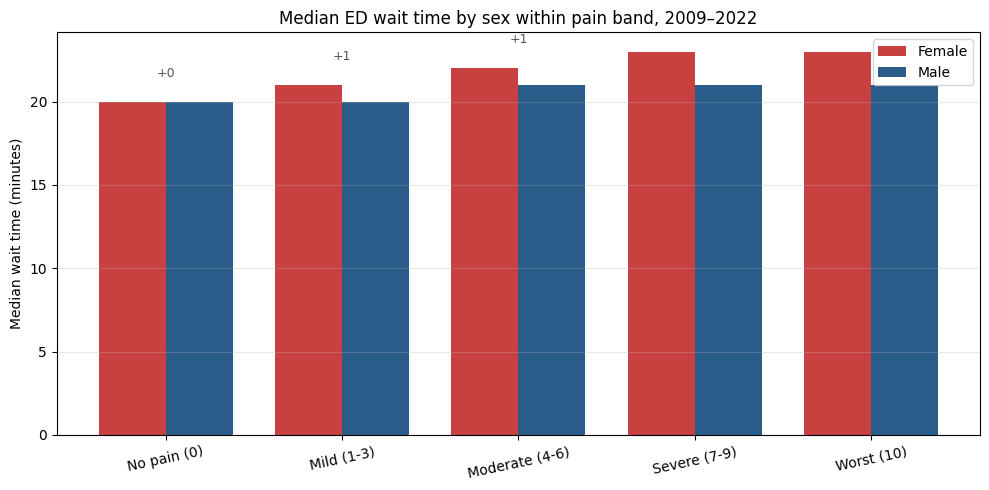

Median wait time by pain band and sex (minutes):


sex_label,Female,Male
pain_band,,
No pain (0),20.0,20.0
Mild (1-3),21.0,20.0
Moderate (4-6),22.0,21.0
Severe (7-9),23.0,21.0
Worst (10),23.0,21.0


In [16]:
PAIN_BANDS = {
    "No pain (0)": (0, 0),
    "Mild (1-3)": (1, 3),
    "Moderate (4-6)": (4, 6),
    "Severe (7-9)": (7, 9),
    "Worst (10)": (10, 10),
}
BAND_ORDER = list(PAIN_BANDS)


def assign_band(score):
    for label, (lo, hi) in PAIN_BANDS.items():
        if lo <= score <= hi:
            return label
    return np.nan


pain = (
    data[data["YEAR"] >= 2009]
    .dropna(subset=["WAITTIME", "PAINSCALE", "sex_label"])
    .copy()
)
pain["pain_band"] = pain["PAINSCALE"].apply(assign_band)

band_wait = (
    pain.dropna(subset=["pain_band"])
    .groupby(["pain_band", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
    .reindex(BAND_ORDER)
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(BAND_ORDER))
w = 0.38
ax.bar(x - w / 2, band_wait["Female"], w, label="Female", color="#C94040")
ax.bar(x + w / 2, band_wait["Male"], w, label="Male", color="#2A5C8A")
ax.set_xticks(x)
ax.set_xticklabels(BAND_ORDER, rotation=12)
ax.set_ylabel("Median wait time (minutes)")
ax.set_title("Median ED wait time by sex within pain band, 2009–2022")
ax.legend()
ax.grid(axis="y", alpha=0.3)

for i, (f, m) in enumerate(zip(band_wait["Female"], band_wait["Male"])):
    if not (np.isnan(f) or np.isnan(m)):
        ax.annotate(
            f"{f - m:+.0f}", (i, max(f, m) + 1.5), ha="center", fontsize=9, color="#555"
        )

plt.tight_layout()
plt.show()

print("Median wait time by pain band and sex (minutes):")
band_wait.round(1)


### What we learned from the dataset

Three things, summarised from the cells above:

1. **The disparity is robust over time.** Median ED wait time for women is at least as long as for men in essentially every year where `WAITTIME` is reliably populated. The pattern is not a quirk of one year, one hospital sample, or one coding regime.
2. **It survives the obvious controls.** When we restrict to **the same triage acuity** (the nurse's own urgency judgement) and to **the same self-reported pain level**, the gap does not disappear. In some bands it widens. That rules out the simplest counter-arguments — "they came in for less urgent things" and "they were in less pain" — using NHAMCS's own variables.
3. **What the dataset cannot do.** NHAMCS captures process (how the visit unfolded) but not outcome (what happened after discharge). So we can document a disparity in *how long patients wait* with high confidence; we cannot, from this dataset alone, claim that the wait gap *causes* worse health outcomes. That separation is important for the framing in the final story.

No machine-learning models are used in this project. The analysis is fully descriptive: group medians, conditional medians, and percentile comparisons. We considered a regression to "control for everything at once" but rejected it: with a non-expert audience, two clearly labelled bar charts conditioning on acuity and pain communicate the finding more faithfully than a coefficient table.


# Dataset Genre

## Which genre of data story?

Using Segal & Heer's seven genres (*Narrative Visualization: Telling Stories with Data*, 2010), our story is best described as a **partitioned poster** combined with an **interactive slideshow**, sitting near the *author-driven → reader-driven* midpoint. The website unfolds as a vertical scroll:

- A **hero** with the headline claim and three key statistics.
- A **quiz / personal hook** where the reader inputs pain score and triage level and immediately sees a personalised comparison.
- A series of **slides** (sections), each anchored by one main chart and a short paragraph of explanatory text.
- An **explorer** at the end where the reader can switch presenting complaint, pain level, and metric, and the chart updates in place.

The author drives the order in which the evidence is encountered, but the reader can stop, re-set, and re-query at every step. That author-led-but-reader-explorable shape is closest to Segal & Heer's *partitioned poster* and *interactive slideshow* genres.

## Visual Narrative tools (Segal & Heer, Figure 7)

The Visual Narrative axis covers three categories: **Visual Structuring**, **Highlighting**, and **Transition Guidance**.

- **Visual Structuring** — *Consistent Visual Platform* and *Progress Bar / Section Anchors.* The site has a fixed navigation strip at the top of every section, and each section follows the same template (section label → headline → body → chart). The reader always knows where they are in the story. We chose this because the data is unfamiliar to most readers; reducing the visual cognitive load lets them spend their attention on the chart rather than on figuring out the layout.
- **Highlighting** — *Colour, Annotation, and Motion.* The story uses two anchor colours throughout — coral (`#C94040`) for the female series, blue (`#2A5C8A`) for the male series — so the reader internalises the colour-to-sex mapping once and reads every later chart faster. Critical numbers (the wait-gap minutes) are annotated directly on the bars rather than left to the eye. The animated regional map fades between years so the persistence of the gap reads as motion. We chose this because the gap itself is small in absolute terms; without explicit annotation the reader's eye would not catch it.
- **Transition Guidance** — *Familiar Objects (a clock face) and Continuity Editing.* The interactive quiz uses a literal analogue clock face to render wait time, because minutes-on-a-clock is a more readable representation of a wait than a horizontal bar. Between sections we use scroll-cued fade-ins rather than hard cuts, so the reader's eye carries the visual context from one section to the next. We chose this so the transition from "personal hook" to "national pattern" does not feel like a context switch.

## Narrative Structure tools (Segal & Heer, Figure 7)

The Narrative Structure axis covers three categories: **Ordering**, **Interactivity**, and **Messaging**.

- **Ordering** — *Linear, author-set order with anchor points.* Scrolling is the primary navigation; the reader meets the evidence in a fixed sequence — hook, then headline gap, then controls (acuity, pain), then regional view, then the "what does +N minutes mean" framing. The nav bar lets a returning reader jump straight to a section, but on first read the order is enforced. We chose linearity because the controls (acuity, pain) only land emotionally *after* the reader has seen the raw gap.
- **Interactivity** — *Filter / Drill-down and Hover.* The personal-hook quiz is a parameterised view: change two inputs, see the comparison. The explorer at the end of the page lets the reader pick a presenting complaint and pain level and watch the metric cards re-compute. The regional map exposes per-region values on hover. We chose these specific affordances because they answer the reader's most likely follow-up questions ("what about me? what about chest pain? what about the West?") without bouncing them into a separate dashboard.
- **Messaging** — *Headlines, Annotations, and Captions / Labels.* Every section has an explicit headline that states what to take from the chart, the chart itself carries inline annotations of the key number, and the body paragraph below frames what the number does *not* prove (e.g. it does not show worse outcomes, only longer process). We chose this layered messaging because the topic is socially loaded; over-claiming is worse than under-claiming, and explicit captions limit the inferences a quick reader can make.

In short: **author-driven enough** that a casual reader gets a clear narrative on a single scroll, **reader-driven enough** that anyone who wants to interrogate a sub-population can do so without leaving the page.


# Contributions

- Aryan:
- Trinity:
- Vladyslav: